# Ensemble Forecasting Evaluation Demo

This demo notebook evaluates and compares a 3-point moving average forecasting method against a naive last-value baseline on a synthetic time-series dataset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

_pip('tabulate==0.9.0')

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'scikit-learn==1.6.1', 'scipy==1.16.3')


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires scikit-learn>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import urllib.request
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e14940-algorithmically-weighted-ensemble-foreca/main/round-2/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print("Loaded data successfully:", list(data.keys()))

Loaded data successfully: ['metrics_agg', 'datasets']


## Configuration
Set tunable parameters for generating synthetic time-series data and evaluation.

In [4]:
RANDOM_SEED = 42
SERIES_LENGTH = 50
WINDOW_SIZE = 3

## Processing & Evaluation
Generate synthetic series, compute moving average and naive predictions, and calculate Mean Squared Error (MSE).

In [5]:
np.random.seed(RANDOM_SEED)
series = np.cumsum(np.random.randn(SERIES_LENGTH)) + 100

actuals = series[WINDOW_SIZE:]
ma_preds = []
naive_preds = []

for i in range(WINDOW_SIZE, len(series)):
    ma_preds.append(np.mean(series[i - WINDOW_SIZE:i]))
    naive_preds.append(series[i - 1])

ma_preds = np.array(ma_preds)
naive_preds = np.array(naive_preds)

ma_mse = np.mean((actuals - ma_preds) ** 2)
naive_mse = np.mean((actuals - naive_preds) ** 2)

print(f"Moving Average MSE: {ma_mse:.4f}")
print(f"Naive Baseline MSE: {naive_mse:.4f}")

Moving Average MSE: 1.5947
Naive Baseline MSE: 0.9483


## Results & Visualization
Plot the time series along with the actual vs predicted values.

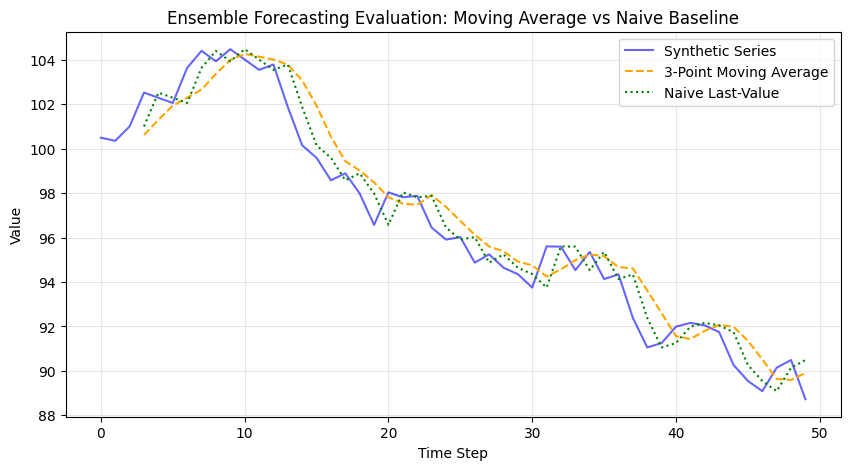

╒═══════════════════════════╤════════╕
│ Model                     │    MSE │
╞═══════════════════════════╪════════╡
│ 3-Point Moving Average    │ 1.5947 │
├───────────────────────────┼────────┤
│ Naive Last-Value Baseline │ 0.9483 │
╘═══════════════════════════╧════════╛


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(series, label='Synthetic Series', color='blue', alpha=0.6)
plt.plot(np.arange(WINDOW_SIZE, len(series)), ma_preds, label='3-Point Moving Average', color='orange', linestyle='--')
plt.plot(np.arange(WINDOW_SIZE, len(series)), naive_preds, label='Naive Last-Value', color='green', linestyle=':')
plt.title('Ensemble Forecasting Evaluation: Moving Average vs Naive Baseline')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary table
summary_table = [
    ["3-Point Moving Average", f"{ma_mse:.4f}"],
    ["Naive Last-Value Baseline", f"{naive_mse:.4f}"]
]
print(tabulate(summary_table, headers=["Model", "MSE"], tablefmt="fancy_grid"))